In [ ]:
import psycopg2
import pandas as pd
conn = psycopg2.connect(host = "localhost",
                        port = 5433 ,
                        database = "Nothwind",
                        user = "postgres", 
                        password = "")

In [41]:
#¿Cuántos empleados tenemos contratados en 'Global Importaciones'? Indica su id, nombre, apellido, ciudad y país.
sql_query = '''SELECT employee_id ,CONCAT(first_name,' ',last_name) AS "empleado", city, country 
FROM employees'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
empleados = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
empleados = empleados.set_axis(colnames, axis = 1)
empleados


,employee_id,empleado,city,country
0,1,Nancy Davolio,Seattle,USA
1,2,Andrew Fuller,Tacoma,USA
2,3,Janet Leverling,Kirkland,USA
3,4,Margaret Peacock,Redmond,USA
4,5,Steven Buchanan,London,UK
5,6,Michael Suyama,London,UK
6,7,Robert King,London,UK
7,8,Laura Callahan,Seattle,USA
8,9,Anne Dodsworth,London,UK


In [42]:
#¿Qué productos tenemos? Indica el id del producto, id del proveedor, nombre del producto, precio por unidad, unidades en stock, unidades pedidas al proveedor y productos descontinuados.
sql_query = '''SELECT product_id ,supplier_id, product_name, unit_price, units_in_stock, units_on_order, discontinued
FROM products'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
productos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
productos = productos.set_axis(colnames, axis = 1)
productos

,product_id,supplier_id,product_name,unit_price,units_in_stock,units_on_order,discontinued
0,1,8,Chai,18.00,39,0,1
1,2,1,Chang,19.00,17,40,1
2,3,1,Aniseed Syrup,10.00,13,70,0
3,4,2,Chef Anton's Cajun Seasoning,22.00,53,0,0
4,5,2,Chef Anton's Gumbo Mix,21.35,0,0,1
...,...,...,...,...,...,...,...
72,73,17,Röd Kaviar,15.00,101,0,0
73,74,4,Longlife Tofu,10.00,4,20,0
74,75,12,Rhönbräu Klosterbier,7.75,125,0,0
75,76,23,Lakkalikööri,18.00,57,0,0


In [44]:
#¿Tenemos productos descontinuados?. Indica el nombre del producto, y cantidad que nos queda en stock. El atributo Discontinued es un booleano: si es igual a 1 el producto ha sido descontinuado.)
sql_query = '''SELECT  product_name, units_in_stock,  discontinued
FROM products 
WHERE discontinued = 1'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
productos_descontinuados = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
productos_descontinuados = productos_descontinuados.set_axis(colnames, axis = 1)
productos_descontinuados

,product_name,units_in_stock,discontinued
0,Chai,39,1
1,Chang,17,1
2,Chef Anton's Gumbo Mix,0,1
3,Mishi Kobe Niku,29,1
4,Alice Mutton,0,1
5,Guaraná Fantástica,20,1
6,Rössle Sauerkraut,26,1
7,Thüringer Rostbratwurst,0,1
8,Singaporean Hokkien Fried Mee,26,1
9,Perth Pasties,0,1


In [45]:
#¿Qué proveedores tenemos? Indica el id de la compañía, nombre de la compañía, ciudad y país.
sql_query = '''SELECT  supplier_id, company_name,  city, country
FROM suppliers'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
proveedores = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
proveedores = proveedores.set_axis(colnames, axis = 1)
proveedores

,supplier_id,company_name,city,country
0,1,Exotic Liquids,London,UK
1,2,New Orleans Cajun Delights,New Orleans,USA
2,3,Grandma Kelly's Homestead,Ann Arbor,USA
3,4,Tokyo Traders,Tokyo,Japan
4,5,Cooperativa de Quesos 'Las Cabras',Oviedo,Spain
5,6,Mayumi's,Osaka,Japan
6,7,"Pavlova, Ltd.",Melbourne,Australia
7,8,"Specialty Biscuits, Ltd.",Manchester,UK
8,9,PB Knäckebröd AB,Göteborg,Sweden
9,10,Refrescos Americanas LTDA,Sao Paulo,Brazil


In [46]:
#¿Qué pedidos hemos tenido? Indica el número de pedido, id del cliente,id del transportista, dia del pedido, día requerido de llegada y día de llegada real.
sql_query = '''SELECT  order_id, customer_id,  ship_via, order_date, required_date, shipped_date
FROM orders'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
pedidos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
pedidos = pedidos.set_axis(colnames, axis = 1)
pedidos

,order_id,customer_id,ship_via,order_date,required_date,shipped_date
0,10248,VINET,3,1996-07-04,1996-08-01,1996-07-16
1,10249,TOMSP,1,1996-07-05,1996-08-16,1996-07-10
2,10250,HANAR,2,1996-07-08,1996-08-05,1996-07-12
3,10251,VICTE,1,1996-07-08,1996-08-05,1996-07-15
4,10252,SUPRD,2,1996-07-09,1996-08-06,1996-07-11
...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05,1998-06-02,None
826,11074,SIMOB,2,1998-05-06,1998-06-03,None
827,11075,RICSU,2,1998-05-06,1998-06-03,None
828,11076,BONAP,2,1998-05-06,1998-06-03,None


In [47]:
#¿Cuántos pedidos hemos tenido?
sql_query = '''SELECT  count(order_id) AS "Total pedidos"
FROM orders'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
pedidos_tot = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
pedidos_tot = pedidos_tot.set_axis(colnames, axis = 1)
pedidos_tot

,Total pedidos
0,830


In [48]:
#¿Cuántos clientes tenemos? Indica el id del cliente, nombre de la compañía, ciudad y país.
sql_query = '''SELECT  customer_id, company_name,  city, country
FROM customers'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
clientes = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
clientes = clientes.set_axis(colnames, axis = 1)
clientes

,customer_id,company_name,city,country
0,ALFKI,Alfreds Futterkiste,Berlin,Germany
1,ANATR,Ana Trujillo Emparedados y helados,México D.F.,Mexico
2,ANTON,Antonio Moreno Taquería,México D.F.,Mexico
3,AROUT,Around the Horn,London,UK
4,BERGS,Berglunds snabbköp,Luleå,Sweden
...,...,...,...,...
86,WARTH,Wartian Herkku,Oulu,Finland
87,WELLI,Wellington Importadora,Resende,Brazil
88,WHITC,White Clover Markets,Seattle,USA
89,WILMK,Wilman Kala,Helsinki,Finland


In [22]:
sql_query = '''SELECT  count(customer_id) AS "Total Clientes"
FROM customers'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall()
colnames = [desc[0] for desc in cursor.description]
clientes_tot = pd.DataFrame(rows, columns=colnames)
clientes_tot

,Total Clientes
0,91


In [49]:
#¿Con qué empresas de transporte trabajamos? Indica su id del transportista y el nombre de la compañía
sql_query = '''SELECT  shipper_id, company_name
FROM shippers'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
trans = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
trans = trans.set_axis(colnames, axis = 1)
trans

,shipper_id,company_name
0,1,Speedy Express
1,2,United Package
2,3,Federal Shipping
3,4,Alliance Shippers
4,5,UPS
5,6,DHL


In [50]:
#¿Cómo son las relaciones de reporte de resultados entre los empleados?
sql_query = '''SELECT  employee_id, concat(first_name,' ',last_name) as "nombre", reports_to
FROM employees'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
trab = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
trab = trab.set_axis(colnames, axis = 1)
trab

,employee_id,nombre,reports_to
0,1,Nancy Davolio,2.0
1,2,Andrew Fuller,NaN
2,3,Janet Leverling,2.0
3,4,Margaret Peacock,2.0
4,5,Steven Buchanan,2.0
5,6,Michael Suyama,5.0
6,7,Robert King,5.0
7,8,Laura Callahan,2.0
8,9,Anne Dodsworth,5.0


In [51]:
#DF con pedidos y clientes
df_ped_clien = clientes.merge(pedidos, how = 'outer', left_on = 'customer_id',right_on = 'customer_id')
df_ped_clien

,customer_id,company_name,city,country,order_id,ship_via,order_date,required_date,shipped_date
0,ALFKI,Alfreds Futterkiste,Berlin,Germany,10643.0,1.0,1997-08-25,1997-09-22,1997-09-02
1,ALFKI,Alfreds Futterkiste,Berlin,Germany,10692.0,2.0,1997-10-03,1997-10-31,1997-10-13
2,ALFKI,Alfreds Futterkiste,Berlin,Germany,10702.0,1.0,1997-10-13,1997-11-24,1997-10-21
3,ALFKI,Alfreds Futterkiste,Berlin,Germany,10835.0,3.0,1998-01-15,1998-02-12,1998-01-21
4,ALFKI,Alfreds Futterkiste,Berlin,Germany,10952.0,1.0,1998-03-16,1998-04-27,1998-03-24
...,...,...,...,...,...,...,...,...,...
827,WOLZA,Wolski Zajazd,Warszawa,Poland,10792.0,3.0,1997-12-23,1998-01-20,1997-12-31
828,WOLZA,Wolski Zajazd,Warszawa,Poland,10870.0,3.0,1998-02-04,1998-03-04,1998-02-13
829,WOLZA,Wolski Zajazd,Warszawa,Poland,10906.0,3.0,1998-02-25,1998-03-11,1998-03-03
830,WOLZA,Wolski Zajazd,Warszawa,Poland,10998.0,2.0,1998-04-03,1998-04-17,1998-04-17


In [52]:
#Creación del DataFrame de productos, proveedores y detalles de los pedidos
sql_query = '''SELECT p.product_id, p.product_name , p.unit_price , p.units_in_stock , p.units_on_order , p.discontinued , s.supplier_id , s.company_name , s.city , s.country , od.order_id, od.unit_price , od.quantity , od.discount 
FROM products AS p
FULL JOIN suppliers AS s
ON p.supplier_id = s.supplier_id
FULL JOIN order_details AS od
ON od.product_id = p.product_id
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
df_prod_prov_od = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
df_prod_prov_od = df_prod_prov_od.set_axis(colnames, axis = 1)
df_prod_prov_od

,product_id,product_name,unit_price,units_in_stock,units_on_order,discontinued,supplier_id,company_name,city,country,order_id,unit_price,quantity,discount
0,11,Queso Cabrales,21.00,22,30,0,5,Cooperativa de Quesos 'Las Cabras',Oviedo,Spain,10248,14.00,12,0.00
1,42,Singaporean Hokkien Fried Mee,14.00,26,0,1,20,Leka Trading,Singapore,Singapore,10248,9.80,10,0.00
2,72,Mozzarella di Giovanni,34.80,14,0,0,14,Formaggi Fortini s.r.l.,Ravenna,Italy,10248,34.80,5,0.00
3,14,Tofu,23.25,35,0,0,6,Mayumi's,Osaka,Japan,10249,18.60,9,0.00
4,51,Manjimup Dried Apples,53.00,20,0,0,24,"G'day, Mate",Sydney,Australia,10249,42.40,40,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,64,Wimmers gute Semmelknödel,33.25,22,80,0,12,Plutzer Lebensmittelgroßmärkte AG,Frankfurt,Germany,11077,33.25,2,0.03
2151,66,Louisiana Hot Spiced Okra,17.00,4,100,0,2,New Orleans Cajun Delights,New Orleans,USA,11077,17.00,1,0.00
2152,73,Röd Kaviar,15.00,101,0,0,17,Svensk Sjöföda AB,Stockholm,Sweden,11077,15.00,2,0.01
2153,75,Rhönbräu Klosterbier,7.75,125,0,0,12,Plutzer Lebensmittelgroßmärkte AG,Frankfurt,Germany,11077,7.75,4,0.00


In [53]:
#Haz un estudio de la evolución de los pedidos realizados a lo largo del tiempo. Para ello primero realiza la query necesaria para obtener los meses, años y pedidos durante cada mes. A continuación crea una línea temporal para ver dicha evolución
sql_query = '''SELECT  extract(YEAR FROM order_date) as "Año", extract(MONTH FROM order_date) as "Mes", count(order_id)
FROM orders
GROUP BY extract(YEAR FROM order_date), extract(MONTH FROM order_date)
ORDER BY extract(YEAR FROM order_date), extract(MONTH FROM order_date) ASC'''
cursor = conn.cursor() 
cursor.execute(sql_query) 
rows = cursor.fetchall() 
ord = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description] 
ord = ord.set_axis(colnames, axis = 1)
ord


,Año,Mes,count
0,1996,7,22
1,1996,8,25
2,1996,9,23
3,1996,10,26
4,1996,11,25
5,1996,12,31
6,1997,1,33
7,1997,2,29
8,1997,3,30
9,1997,4,31


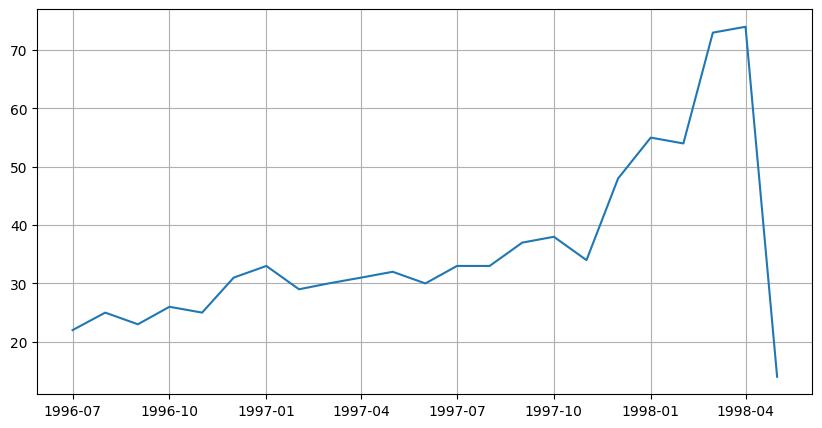

In [54]:
import matplotlib.pyplot as plt
ord["fecha"]=pd.to_datetime(ord["Año"].astype(int).astype(str)+"-"+ord["Mes"].astype(int).astype(str)+"-01")
plt.figure(figsize=(10,5))
plt.plot(ord["fecha"],ord["count"])
plt.grid(True)
plt.show()

In [57]:
#Investiga cuáles son los países donde tenemos más ventas País origen de la compañía). No es necesario realizar una query para obtener el DataFrame. A raíz de estos datos genera una columna con el continente a partir del siguiente diccionario:
continentes = {'Europe': ['Austria', 'Belgium', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland', 'Italy', 'Norway', 'Poland', 'Portugal', 'Spain', 'Sweden', 'Switzerland', 'UK'],'America': ['Argentina', 'Brazil', 'Canada', 'Mexico', 'USA', 'Venezuela'] }

Pedidos_por_pais= df_ped_clien.groupby("country").size().reset_index(name="Num_Pedidos").sort_values("Num_Pedidos")
Pedidos_por_pais


,country,Num_Pedidos
12,Norway,6
13,Poland,7
14,Portugal,13
0,Argentina,16
5,Denmark,18
17,Switzerland,18
2,Belgium,19
9,Ireland,19
6,Finland,22
15,Spain,24


In [58]:
continentes_cambio={}
for clave,valor in continentes.items():
  for e in valor:
    continentes_cambio[e]=clave
df_ped_clien["Continente"]=df_ped_clien['country'].map(continentes_cambio)
df_ped_clien

,customer_id,company_name,city,country,order_id,ship_via,order_date,required_date,shipped_date,Continente
0,ALFKI,Alfreds Futterkiste,Berlin,Germany,10643.0,1.0,1997-08-25,1997-09-22,1997-09-02,Europe
1,ALFKI,Alfreds Futterkiste,Berlin,Germany,10692.0,2.0,1997-10-03,1997-10-31,1997-10-13,Europe
2,ALFKI,Alfreds Futterkiste,Berlin,Germany,10702.0,1.0,1997-10-13,1997-11-24,1997-10-21,Europe
3,ALFKI,Alfreds Futterkiste,Berlin,Germany,10835.0,3.0,1998-01-15,1998-02-12,1998-01-21,Europe
4,ALFKI,Alfreds Futterkiste,Berlin,Germany,10952.0,1.0,1998-03-16,1998-04-27,1998-03-24,Europe
...,...,...,...,...,...,...,...,...,...,...
827,WOLZA,Wolski Zajazd,Warszawa,Poland,10792.0,3.0,1997-12-23,1998-01-20,1997-12-31,Europe
828,WOLZA,Wolski Zajazd,Warszawa,Poland,10870.0,3.0,1998-02-04,1998-03-04,1998-02-13,Europe
829,WOLZA,Wolski Zajazd,Warszawa,Poland,10906.0,3.0,1998-02-25,1998-03-11,1998-03-03,Europe
830,WOLZA,Wolski Zajazd,Warszawa,Poland,10998.0,2.0,1998-04-03,1998-04-17,1998-04-17,Europe


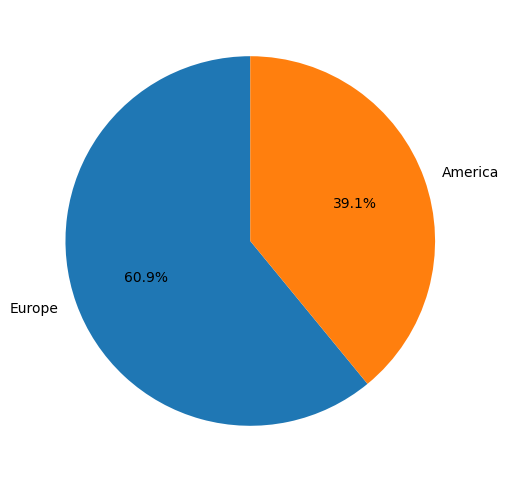

In [59]:
porcentaje_continente = (
    df_ped_clien["Continente"]
    .value_counts(normalize=True) * 100
).reset_index()
porcentaje_continente.columns = ["Continente", "Porcentaje"]
porcentaje_continente
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.pie(
    porcentaje_continente["Porcentaje"],
    labels=porcentaje_continente["Continente"],
    autopct="%1.1f%%",
    startangle=90
)
plt.show()

In [60]:
#Sabemos que algunos pedidos han llegado con retraso, además hay pedidos que no ha sido registrada su llegada. Investiga si la compañía de transporte está relacionada con ello o no. Realiza un boxplot para ver la diferencia de rango intercuartílico.
sql_query = '''SELECT o.shipped_date - o.required_date AS "Retraso", s.company_name
FROM orders AS o
JOIN shippers AS s
ON s.shipper_id = o.ship_via
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
retrasos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
retrasos = retrasos.set_axis(colnames, axis = 1)
retrasos

,Retraso,company_name
0,-16.0,Federal Shipping
1,-37.0,Speedy Express
2,-24.0,United Package
3,-21.0,Speedy Express
4,-26.0,United Package
...,...,...
825,NaN,United Package
826,NaN,United Package
827,NaN,United Package
828,NaN,United Package


<Figure size 2000x1000 with 0 Axes>

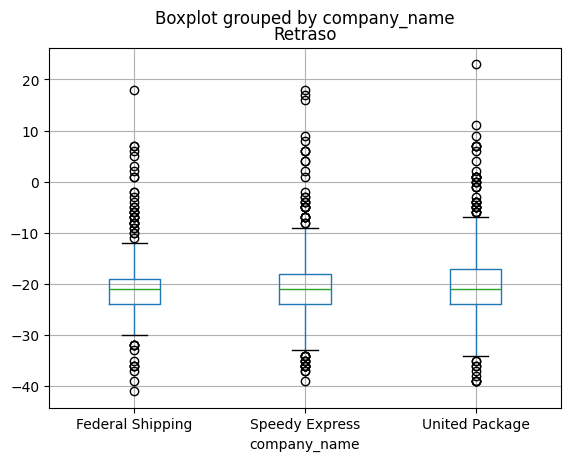

In [63]:
df_retrasos_box = retrasos.dropna(subset=["Retraso"])
plt.figure(figsize=(20,10))
df_retrasos_box.boxplot(
    column="Retraso",
    by="company_name"
)
plt.grid(True)
plt.show()

In [64]:
sql_query = '''SELECT
  100.0 * COUNT(*) FILTER (WHERE o.shipped_date IS NULL) / COUNT(*) AS porcentaje_no_registrados, s.company_name
FROM orders as o
LEFT JOIN shippers AS s
on s.shipper_id = o.ship_via
GROUP BY s.company_name;
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
P_sin_fecha = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
P_sin_fecha = P_sin_fecha.set_axis(colnames, axis = 1)
P_sin_fecha

,porcentaje_no_registrados,company_name
0,2.3529411764705882,Federal Shipping
1,1.6064257028112450,Speedy Express
2,3.3742331288343558,United Package


In [65]:
#Hay bastante diferencia entre el precio pagado en cada pedido. Averigüa la distribución media del precio del pedido por país de procedencia del cliente. Realiza la visualización que creas más conveniente para sacar conclusiones
sql_query = '''
SELECT AVG(Precio_pedido) AS "Precio Promedio", p1.country 
FROM (SELECT o.order_id , sum(od.unit_price*od.quantity) AS Precio_pedido, c.country
FROM orders as o
LEFT JOIN order_details AS od
ON od.order_id = o.order_id
LEFT JOIN customers AS c
ON c.customer_id = o.customer_id
GROUP BY o.order_id, c.country) as p1
GROUP BY p1.country
ORDER BY "Precio Promedio" DESC;
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Precio_pedido_pais = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Precio_pedido_pais = Precio_pedido_pais.set_axis(colnames, axis = 1)
Precio_pedido_pais


,Precio Promedio,country
0,3487.415747,Austria
1,3016.704745,Ireland
2,2160.385082,USA
3,2005.251065,Germany
4,1932.347223,Denmark
5,1849.209491,Belgium
6,1844.470006,Canada
7,1828.861111,Switzerland
8,1608.748647,Sweden
9,1385.162410,Brazil


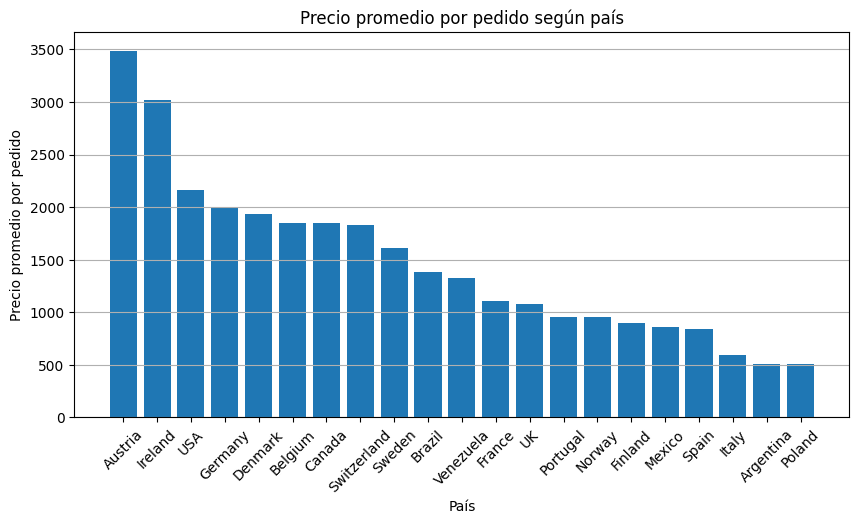

In [66]:
plt.figure(figsize=(10,5))
plt.bar(
    Precio_pedido_pais["country"],
    Precio_pedido_pais["Precio Promedio"]
)
plt.xlabel("País")
plt.ylabel("Precio promedio por pedido")
plt.title("Precio promedio por pedido según país")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [67]:
#Investiga si existen clientes que no hayan pedido nunca. ¿Qué porcentaje de clientes no tienen pedidos registrados?
sql_query = '''SELECT (COUNT(*) FILTER (WHERE PEDIDOS = 0)/COUNT(*))*100.0 AS PROVEEDORES_SIN_PEDIDOS FROM
(SELECT c.company_name , count(o.order_id) AS Pedidos 
FROM customers AS c
LEFT JOIN orders AS o
ON o.customer_id = c.customer_id
GROUP BY c.company_name
ORDER BY count(o.order_id) ASC) AS P1
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Clientes_pedidos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Clientes_pedidos = Clientes_pedidos.set_axis(colnames, axis = 1)
Clientes_pedidos

,proveedores_sin_pedidos
0,0.0


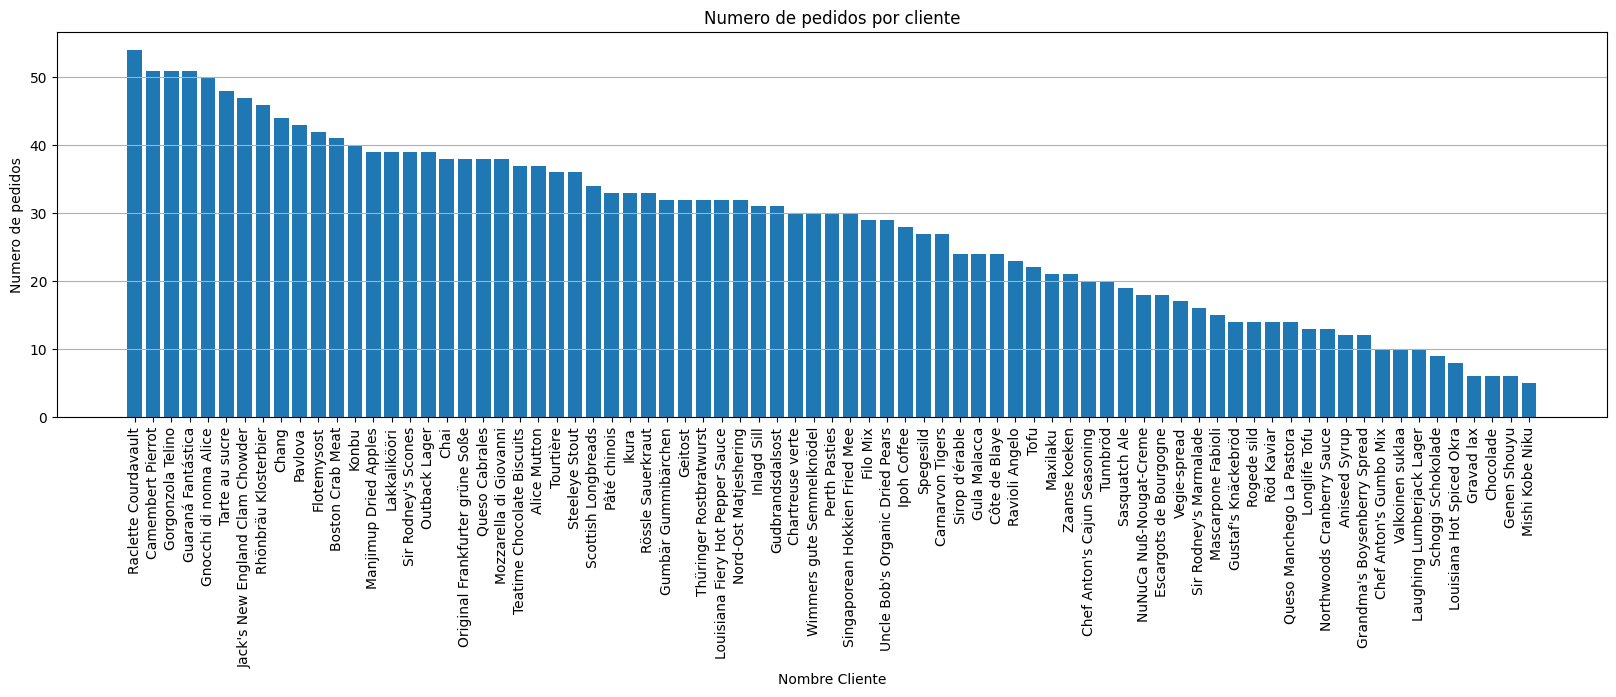

In [68]:
#Estudia los productos más demandados e investiga cuáles corre prisa hacer reestock Los que quedan 20 o menos y no hay unidades pedidas). Realiza la visualización que creas más conveniente para sacar conclusiones.
sql_query = '''SELECT p.product_name , count(od.order_id) 
FROM products AS p
LEFT JOIN order_details AS od
ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY count(od.order_id)  DESC
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Clientes_pedidos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Clientes_pedidos = Clientes_pedidos.set_axis(colnames, axis = 1)
Clientes_pedidos
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.bar(
    Clientes_pedidos["product_name"],
    Clientes_pedidos["count"]
)
plt.xlabel("Nombre Cliente")
plt.ylabel("Numero de pedidos")
plt.title("Numero de pedidos por cliente")
plt.xticks(rotation=90)
plt.grid(axis="y")

plt.show()

In [70]:
sql_query = '''SELECT p.product_name  
FROM products AS p
WHERE p.units_in_stock <=20 AND p.units_on_order=0 AND p.discontinued=0
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Clientes_pedidos = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Clientes_pedidos = Clientes_pedidos.set_axis(colnames, axis = 1)
Clientes_pedidos

,product_name
0,Uncle Bob's Organic Dried Pears
1,Northwoods Cranberry Sauce
2,Gumbär Gummibärchen
3,Nord-Ost Matjeshering
4,Steeleye Stout
5,Côte de Blaye
6,Manjimup Dried Apples
7,Camembert Pierrot
8,Tarte au sucre
9,Mozzarella di Giovanni


In [71]:
#Quiere saber cuándo fue la última vez que se pidió un producto de cada categoría.
sql_query = '''
SELECT c.category_name, MAX(o.order_date)
FROM categories AS c
LEFT JOIN products AS p
ON p.category_id = c.category_id
LEFT JOIN order_details as od
ON od.product_id = p.product_id
LEFT JOIN orders as o
ON o.order_id = od.order_id
GROUP BY c.category_name
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Categ_ultima = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Categ_ultima = Categ_ultima.set_axis(colnames, axis = 1)
Categ_ultima

,category_name,max
0,Beverages,1998-05-06
1,Produce,1998-05-06
2,Condiments,1998-05-06
3,Grains/Cereals,1998-05-06
4,Meat/Poultry,1998-05-06
5,Confections,1998-05-06
6,Dairy Products,1998-05-06
7,Seafood,1998-05-06


In [72]:
#Necesita saber si existe algún producto que nunca se haya vendido por su precio original.
sql_query = ''' SELECT product_name, sum(Precio_Original)
FROM
(SELECT p.product_name, CASE 
WHEN p.unit_price=od.unit_price THEN 1
ELSE 0
END AS Precio_Original
FROM products AS p
LEFT JOIN order_details as od
ON od.product_id = p.product_id) AS P1
GROUP BY product_name
ORDER BY sum(Precio_Original) ASC
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Prod_OP= pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Prod_OP = Prod_OP.set_axis(colnames, axis = 1)
Prod_OP

,product_name,sum
0,Genen Shouyu,0
1,Gravad lax,3
2,Mishi Kobe Niku,4
3,Louisiana Hot Spiced Okra,4
4,Chocolade,4
...,...,...
72,Raclette Courdavault,35
73,Rhönbräu Klosterbier,35
74,Jack's New England Clam Chowder,36
75,Guaraná Fantástica,36


In [74]:
#Quiere tener toda la información necesaria para poder identificar un tipo de producto. En concreto, tienen especial interés por los productos con categoría "Confections". Devuelve el ID del producto, el nombre del producto y su ID de categoría.
sql_query = ''' SELECT p.product_id, p.product_name, p.category_id
FROM products AS p
LEFT JOIN categories AS c
ON c.category_id = p.category_id
WHERE c.category_name = 'Confections'
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Prod_Confections = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Prod_Confections = Prod_Confections.set_axis(colnames, axis = 1)
Prod_Confections

,product_id,product_name,category_id
0,16,Pavlova,3
1,19,Teatime Chocolate Biscuits,3
2,20,Sir Rodney's Marmalade,3
3,21,Sir Rodney's Scones,3
4,25,NuNuCa Nuß-Nougat-Creme,3
5,26,Gumbär Gummibärchen,3
6,27,Schoggi Schokolade,3
7,47,Zaanse koeken,3
8,48,Chocolade,3
9,49,Maxilaku,3


In [75]:
#Quiere saber si existe algún proveedor del que pueda prescindir ya que todos los productos que tiene se encuentran descontinuados.
sql_query = ''' SELECT s.company_name
FROM suppliers AS s
LEFT JOIN products AS p
ON p.supplier_id = s.supplier_id
GROUP BY s.company_name
HAVING count(p.product_id)=sum(p.discontinued)
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Prov_disc = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Prov_disc = Prov_disc.set_axis(colnames, axis = 1)
Prov_disc

,company_name
0,Refrescos Americanas LTDA


In [76]:
#Extraer los clientes que compraron mas de 30 articulos "Chai" en un único pedido
sql_query = ''' SELECT c.company_name
FROM customers AS c
LEFT JOIN orders AS o
ON o.customer_id = c.customer_id
LEFT JOIN order_details AS od
ON od.order_id = o.order_id
LEFT JOIN products AS p
ON p.product_id = od.product_id
WHERE p.product_name = 'Chai' and od.quantity>30

'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Cliente_Chai = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Cliente_Chai = Cliente_Chai.set_axis(colnames, axis = 1)
Cliente_Chai

,company_name
0,QUICK-Stop
1,Lehmanns Marktstand
2,Berglunds snabbköp
3,LINO-Delicateses
4,Save-a-lot Markets
5,Seven Seas Imports
6,Bottom-Dollar Markets
7,Save-a-lot Markets
8,Lehmanns Marktstand


In [78]:
#Indica los clientes cuya suma total de carga en los pedidos sea mayor de 1000
sql_query = ''' SELECT c.company_name
FROM customers AS c
LEFT JOIN orders AS o
ON o.customer_id = c.customer_id
GROUP BY c.company_name
HAVING SUM(o.freight)>1000

'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Cliente_1000 = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Cliente_1000 = Cliente_1000.set_axis(colnames, axis = 1)
Cliente_1000

,company_name
0,Lehmanns Marktstand
1,Mère Paillarde
2,Rattlesnake Canyon Grocery
3,Hungry Owl All-Night Grocers
4,Frankenversand
5,HILARION-Abastos
6,Bon app'
7,Berglunds snabbköp
8,Ernst Handel
9,Great Lakes Food Market


In [79]:
#Desde recursos humanos nos piden seleccionar los nombres de las ciudades con 5 o más empleadas de cara a estudiar la apertura de nuevas oficinas.
sql_query = ''' SELECT e.city, count(employee_id)
FROM employees AS e
GROUP BY e.city
'''
cursor = conn.cursor()
cursor.execute(sql_query)
rows = cursor.fetchall()
Pot_apertura = pd.DataFrame(rows)
colnames = [desc[0] for desc in cursor.description]
Pot_apertura = Pot_apertura.set_axis(colnames, axis = 1)
Pot_apertura

,city,count
0,Redmond,1
1,London,4
2,Tacoma,1
3,Kirkland,1
4,Seattle,2
